- Используя датасет и блокнот с описанием атрибутов вывести топ 5 атрибутов, которые больше всего влияют на изменение SalePrice (желательно с обратной зависимостью включительно)
- Высчитать веса для всех 5 атрибутов(определить степень влияния атрибута на SalePrice)

In [28]:
import pandas as pd
from matplotlib import pyplot as plt

In [29]:
df = pd.read_csv("train_data2.csv")

In [30]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [31]:
df.tail(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [32]:
ovrlq_df = df[["SalePrice","OverallQual", "YearBuilt", "YrSold"]]
grp_df = ovrlq_df.groupby("OverallQual")["SalePrice"].mean() #среднее значение по цене продажи при группировке
grp_df

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

Минимальная средняя цена 50к, средняя 200к, максимальная 438к. Разница минимальной и максимальной цены очень большая, возможно это один из топ5 атрибутов

In [33]:
cars_df = df[["SalePrice", "GarageCars"]]
grp_cars_df = cars_df.groupby("GarageCars")["SalePrice"].mean()
grp_cars_df.sort_values() # сортировка

GarageCars
0    103317.283951
1    128116.688347
2    183851.663835
4    192655.800000
3    309636.121547
Name: SalePrice, dtype: float64

функция для перебора имени столбца

In [34]:
def get_column_name(df, i):
    column_name = df.columns[i]
    return column_name

Получаем среднее значение по каждому атрибуту

In [35]:
all_range = {}
for i in range(1, len(df.columns)):
    name_col = get_column_name(df, i)
    if name_col == "SalePrice":
        continue
    values_col = []
    # считаем только атрибуты с числами в ячейках + проверяем количество уникальных значений в атрибуте, если их слишком много, то среднее значение будет высчитываться со слишком большим разбросом, что не даст полной картины размаха
    if df[name_col].dtype in ["int64", "float64"] and df[name_col].nunique() >= 10:
        # обрезаем количество неуникальных значений до 5
        cuted_col = pd.qcut(df[name_col], 5, duplicates='drop')
        # получаем среднее арифметическое для каждой группы, которые мы получили тут же через groupby
        col_diff = df.groupby(cuted_col)["SalePrice"].mean()
        max_col = col_diff.max()
        values_col.append(max_col)
        min_col = col_diff.min()
        values_col.append(min_col)
        # получаем размах(максимальная цена - минимальная) по каждой группе
        difference_cols = max_col - min_col
        values_col.append(difference_cols)
        # получаем словарь {имя атрибута: [макс,мин, размах]}
        all_range.update({name_col: values_col})

    else:
        # всё то же самое, но в случае когда уникальных значений у атрибута меньше 11 и текстовых атрибутов
        col_diff = df.groupby(name_col)["SalePrice"].mean()
        max_col = col_diff.max()
        values_col.append(max_col)
        min_col = col_diff.min()
        values_col.append(min_col)
        difference_cols = max_col - min_col
        values_col.append(difference_cols)
        all_range.update({name_col: values_col})

# сортируем по индексу 2(там лежит размах)
top5_cols = sorted(all_range.items(), key=lambda x: x[1][2], reverse=True)

print_count = 0
# печатаем словарь - имя атрибута:[максимальное значение атрибута, минимальное, размах]
for column, values in top5_cols:
    if print_count == 5:
        break
    else:
        max_val = values[0]
        min_val = values[1]
        range_val = values[2]
        print_count += 1
        print(f"Атрибут: {column:<15} # Макс: {max_val:>9.2f} # Мин: {min_val:>9.2f} # Размах: \033[31m{range_val:>9.2f}\033[0m")


Атрибут: PoolArea        # Макс: 745000.00 # Мин: 160000.00 # Размах: 585000.00
Атрибут: PoolQC          # Макс: 490000.00 # Мин: 201990.00 # Размах: 288010.00
Атрибут: ExterQual       # Макс: 367360.96 # Мин:  87985.21 # Размах: 279375.75
Атрибут: RoofMatl        # Макс: 390250.00 # Мин: 137000.00 # Размах: 253250.00
Атрибут: Neighborhood    # Макс: 335295.32 # Мин:  98576.47 # Размах: 236718.85


В результат вошли атрибуты у которых очень малое количество домов

In [36]:
df.groupby("PoolArea")["SalePrice"].count()

PoolArea
0      1453
480       1
512       1
519       1
555       1
576       1
648       1
738       1
Name: SalePrice, dtype: int64

То же самое, но с дополнительной фильтрацией групп атрибутов

In [37]:
all_range = {}
for i in range(1, len(df.columns)):
    name_col = get_column_name(df, i)
    if name_col == "SalePrice":
        continue
    values_col = []
    if df[name_col].dtype in ["int64", "float64"] and df[name_col].nunique() >= 10:
        group_by_target = pd.qcut(df[name_col], 5, duplicates='drop')
    else:
        group_by_target = name_col
# подсчитаем среднее арифметическое и количество домов для каждой группы
    group_means = df.groupby(group_by_target)["SalePrice"].mean()
    group_counts = df.groupby(group_by_target)["SalePrice"].count()
# отрежем группы с количеством домов меньше 10
    valid_groups = group_means[group_counts >= 10]
# отрежем группы в которых нельзя подсчитать среднее(т.к. нужно минимум 2 группы в атрибуте что бы считать)
    if len(valid_groups) >= 2:
        max_col = valid_groups.max()
        min_col = valid_groups.min()
        difference_cols = max_col - min_col
        values_col.extend([max_col, min_col, difference_cols])
        all_range.update({name_col: values_col})

top5_cols = sorted(all_range.items(), key=lambda x: x[1][2], reverse=True)
print_count = 0
# печатаем словарь - имя атрибута:[максимальное значение атрибута, минимальное, размах]
for column, values in top5_cols:
    if print_count == 5:
        break
    else:
        max_val = values[0]
        min_val = values[1]
        range_val = values[2]
        print_count += 1
        print(f"Атрибут: {column:<15} # Макс: {max_val:>9.2f} # Мин: {min_val:>9.2f} # Размах: \033[31m{range_val:>9.2f}\033[0m")

Атрибут: ExterQual       # Макс: 367360.96 # Мин:  87985.21 # Размах: 279375.75
Атрибут: Neighborhood    # Макс: 335295.32 # Мин:  98576.47 # Размах: 236718.85
Атрибут: KitchenQual     # Макс: 328554.67 # Мин: 105565.21 # Размах: 222989.46
Атрибут: FullBath        # Макс: 347822.91 # Мин: 134751.44 # Размах: 213071.47
Атрибут: BsmtQual        # Макс: 327041.04 # Мин: 115692.03 # Размах: 211349.01


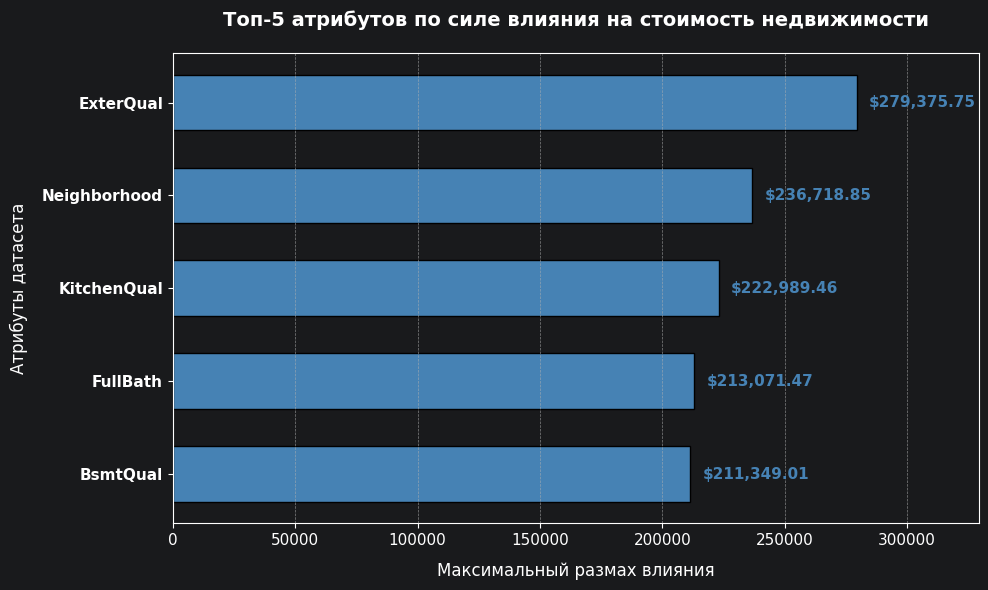

In [38]:
plot_data = []
for column, values in top5_cols[:5]:
    plot_data.append({
        'Атрибут': column,
        'Размах в $': values[2]
    })

df_plot = pd.DataFrame(plot_data)
df_plot = df_plot.iloc[::-1]
plt.figure(figsize=(10, 6))
bars = plt.barh(df_plot['Атрибут'], df_plot['Размах в $'], color='#4682B4', edgecolor='black', height=0.6)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2,
             f"${width:,.2f}",
             va='center', ha='left', fontsize=11, fontweight='bold', color='#4682B4')

plt.title('Топ-5 атрибутов по силе влияния на стоимость недвижимости',
          fontsize=14, fontweight='bold', pad=20, loc='center')
plt.xlabel('Максимальный размах влияния', fontsize=12, labelpad=10)
plt.ylabel('Атрибуты датасета', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, df_plot['Размах в $'].max() + 50000)

plt.tight_layout()


plt.show()

In [60]:
df_cleaned = df[(df["LotArea"] < 25000) & (df["SalePrice"] < 500000)]
x_column = df_cleaned[["LotArea"]]
y_column = df_cleaned[["SalePrice"]]

In [61]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array(x_column)
y = np.array(y_column)
reg = LinearRegression().fit(X, y)

reg

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[8.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[100692.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[136106.93]


In [62]:
print("a = ", reg.coef_)
print("b = ", reg.intercept_)

a =  [[8.05442198]]
b =  [100691.99673871]


"SalePrice" = 2.1*"LotArea" + 158836


In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2)

In [64]:
reg = LinearRegression().fit(X_train, y_train)

In [65]:
print("a = ", reg.coef_)
print("b = ", reg.intercept_)

a =  [[8.20537132]]
b =  [100263.40204258]


In [66]:
test_result = reg.predict(X_test)
test_result

array([[196266.24645228],
       [185303.87037268],
       [205472.67307004],
       [174111.7438962 ],
       [169598.78967181],
       [186255.69344546],
       [179650.36953522],
       [203979.29549033],
       [167317.69644567],
       [196266.24645228],
       [170271.63011981],
       [150480.27450304],
       [199466.34126594],
       [190850.70138302],
       [132937.19062715],
       [176737.46271766],
       [166004.83703493],
       [179034.96668644],
       [175219.469024  ],
       [159342.07552547],
       [179034.96668644],
       [172142.4547801 ],
       [237596.70177636],
       [182317.11521327],
       [170009.05823766],
       [195060.05686868],
       [164774.03133737],
       [175646.14833249],
       [167957.7154084 ],
       [174604.06617522],
       [228086.67641988],
       [127981.14635164],
       [188881.41226692],
       [116288.49222481],
       [118971.6486455 ],
       [174932.28102791],
       [163920.6727204 ],
       [185558.23688351],
       [1462

In [67]:
reg.score(X_test, y_test)

0.1562898323188212

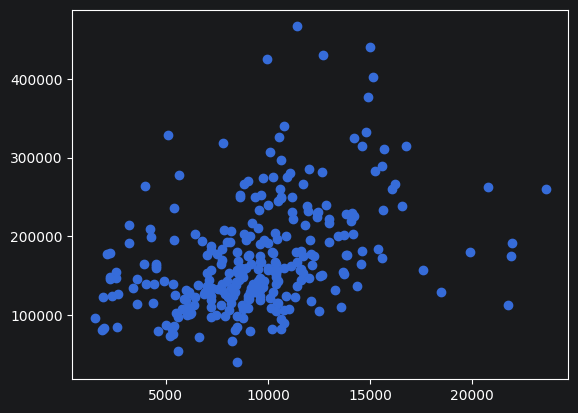

In [68]:

plt.scatter(X_test, y_test)

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, test_result)
mse = mean_squared_error(y_test, test_result)
print ("MAE = ", mae)
print ("MSE = ", mse)

MAE =  49555.67731943495
MSE =  4145224912.4331036
